# **LePHARE Performances & Chi2 Stats**

Preliminary work for star-gal separation. Performs statistics on lephare outputs carried on two synthetic magnitude libraries (one composed of star SED, another of galaxies SEDs).

## **Initialization**

### Packages

In [1]:
### Libs ###
from imports import *

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)

# Custom libraries
from scripts import statsplot as ssp
from scripts import utils as sutils

%matplotlib inline

### Catalog

In [2]:
#--- Generate pandas df from output catalog ---

#--- DC1 ---
# CAT_OUT = os.path.join(base_dir, 'catalogs/DC1/DC1_Buzzard_PICKLES_LSST.out')
CAT_OUT = os.path.join(base_dir, 'catalogs/DC1/DC1_Buzzard_BT_LSST.out')

#--- DC2 ---
# CAT_OUT = os.path.join(base_dir, 'catalogs/DC2/dp02_dc2_62_BT_LSST_full.out')

#--- DES stars ---
# CAT_OUT = os.path.join(base_dir, 'catalogs/DES/DES_STARCAT/WORK_COMPLETE2/zphota/DESstars_Buzzard_BT_DES.out')

#--- DP1 ---
# CAT_OUT = os.path.join(base_dir, 'catalogs/DP1/DP1ecdfs_buzzard_BT_LSST_full.out')

photoz_cat = sutils.lephare_to_pandas(CAT_OUT)
### Clean error values
photoz_cat = photoz_cat[photoz_cat['Z_BEST'] != -99.9]

In [3]:
### error mag bining
photoz_cat_errmag0001 = photoz_cat[photoz_cat['ERR_MAG_OBS1']<=0.01]
photoz_cat_errmag001 = photoz_cat[(photoz_cat['ERR_MAG_OBS1']>0.01) & (photoz_cat['ERR_MAG_OBS1']<=0.1)]
photoz_cat_errmag01 = photoz_cat[(photoz_cat['ERR_MAG_OBS1']>0.1)]# & (photoz_cat['ERR_MAG_OBS1']<=1)]
#photoz_cat_errmag1 = photoz_cat[(photoz_cat['ERR_MAG_OBS1']>1)]

### mag bining
photoz_cat_mag20 = photoz_cat[photoz_cat['MAG_OBS1']<=20]
photoz_cat_mag23 = photoz_cat[(photoz_cat['MAG_OBS1']>20) & (photoz_cat['MAG_OBS1']<=23)]
photoz_cat_mag26 = photoz_cat[(photoz_cat['MAG_OBS1']>23) & (photoz_cat['MAG_OBS1']<=26)]
photoz_cat_mag27 = photoz_cat[(photoz_cat['MAG_OBS1']>26)]



In [4]:
photoz_cat_magbin = (photoz_cat_mag27, photoz_cat_mag26, photoz_cat_mag23, photoz_cat_mag20)
photoz_cat_magbin_labels = ['Gmag > 26', 'Gmag < 26', 'Gmag < 23', 'Gmag < 20']
photoz_cat_emagbin = (photoz_cat_errmag01, photoz_cat_errmag001, photoz_cat_errmag0001)
photoz_cat_emagbin_labels = ['Gemag > 0.1', 'Gemag < 0.1', 'Gemag < 0.01']

## **Performance plots**

### zz-plot

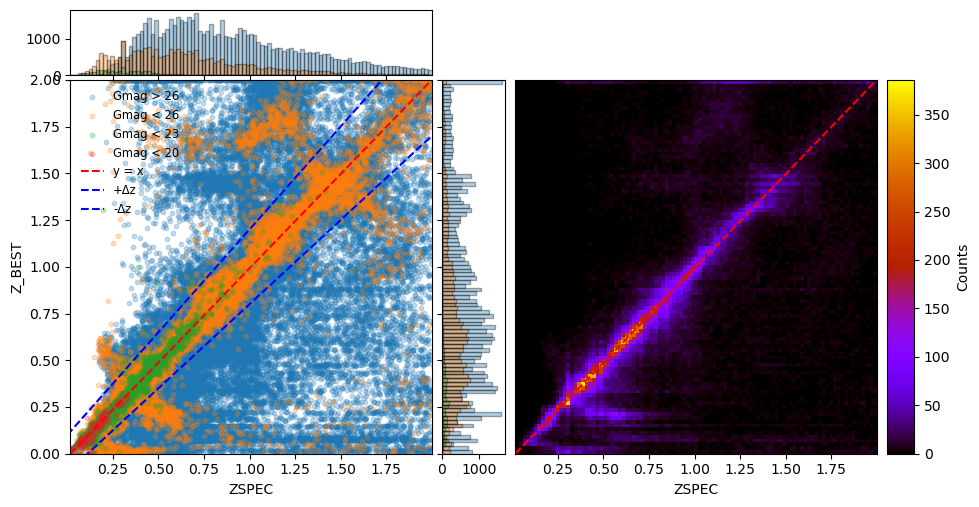

In [5]:
ssp.scatter_vs_hist2D(data=photoz_cat_magbin, cmaps='gnuplot', deltaz=0.1, labels=photoz_cat_magbin_labels, xlabel='ZSPEC', ylabel='Z_BEST')

You rather use this one if you don't have z specs:

In [6]:
# #Plot z hist
# ssp.histograms(photoz_cat_emagbin, xrange=(0,2), labels=photoz_cat_emagbin_labels)

### pit and qq-plot

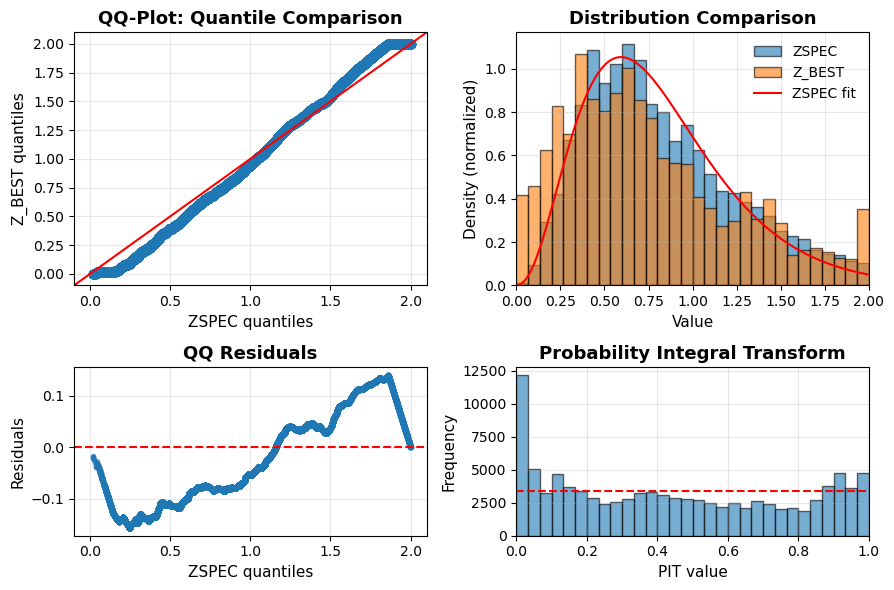

In [7]:
ssp.pit_qqplot(data = photoz_cat)

## **Chi2 stats**

/home/hallouin/Documents/t_hall/lephare/stargal/scripts/statsplot.py:444: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


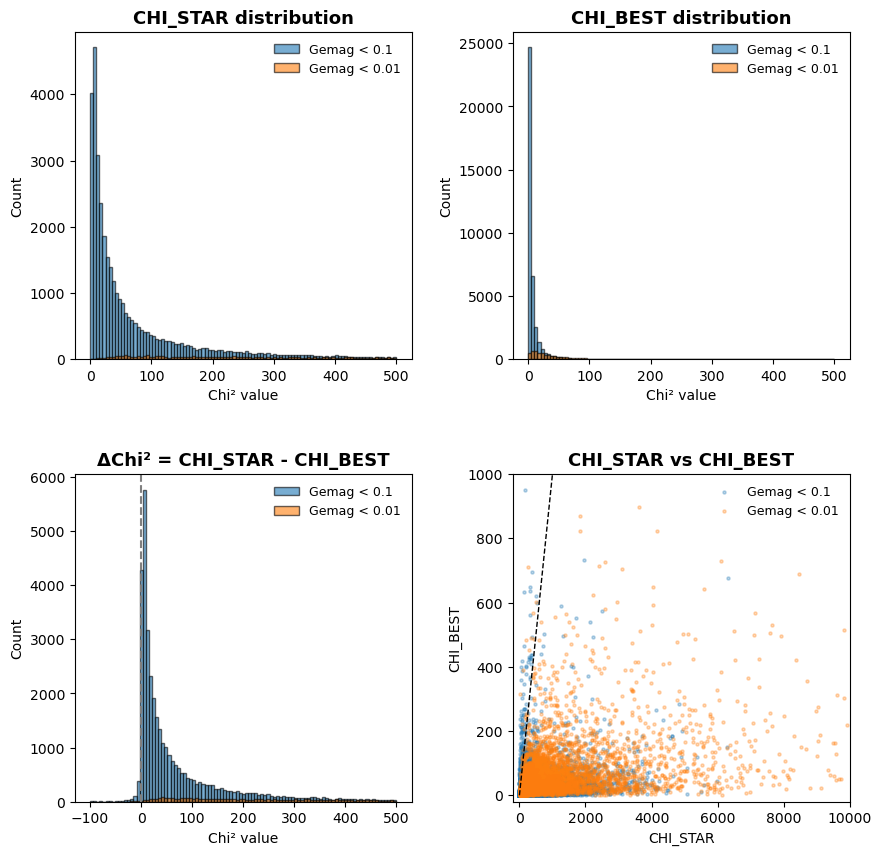

In [8]:
# %matplotlib widget

ssp.chi_stats(data = photoz_cat_emagbin[1:3], mask_min=-100, mask_max=500, bins=100, scatter_xlim=(-200, 10000), scatter_ylim=(-20, 1000), labels=photoz_cat_emagbin_labels[1:3])

/home/hallouin/Documents/t_hall/lephare/stargal/scripts/statsplot.py:638: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scatter.legend(loc='upper left', fontsize=8, frameon=False)
/home/hallouin/Documents/t_hall/lephare/stargal/scripts/statsplot.py:651: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scatter.legend(loc='upper left', fontsize=8, frameon=False)
/home/hallouin/Documents/t_hall/lephare/stargal/scripts/statsplot.py:664: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scatter.legend(loc='upper left', fontsize=8, frameon=False)
/home/hallouin/Documents/t_hall/lephare/stargal/scripts/statsplot.py:669:

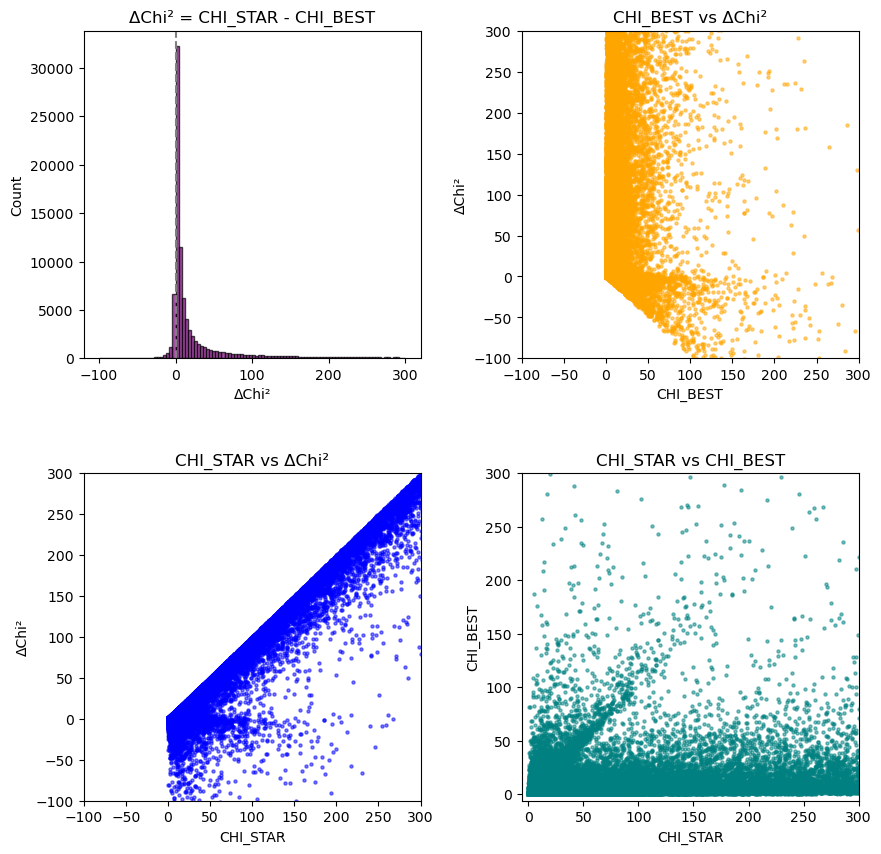

In [9]:
ssp.more_chi_stats(data = photoz_cat, mask_min=-100, mask_max=300, bins=100)

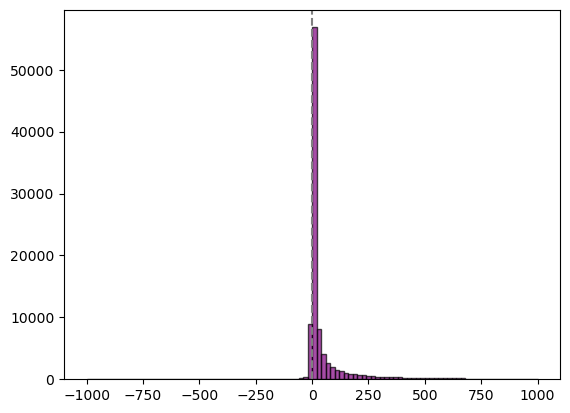

In [10]:
plt.figure()
delta_chi=photoz_cat['CHI_STAR'] - photoz_cat['CHI_BEST']
hist_range = (-1000,1000)
plt.hist(delta_chi, bins=100, alpha=0.7, edgecolor='black', color='purple', range=hist_range)
plt.axvline(0, color='gray', linestyle='--')
plt.show()

Temporary TRASH - flag VS stype

In [11]:
#--- DES binning ---

# ### error observed mag bining
# photoz_des_errmag001 = photoz_des[photoz_des['ERR_MAG_OBS1']<0.002]
# photoz_des_errmag002 = photoz_des[(photoz_des['ERR_MAG_OBS1']>=0.002) & (photoz_des['ERR_MAG_OBS1']<0.003)]
# photoz_des_errmag003 = photoz_des[(photoz_des['ERR_MAG_OBS1']>=0.003) & (photoz_des['ERR_MAG_OBS1']<=0.1)]
# photoz_des_errmag1 = photoz_des[(photoz_des['ERR_MAG_OBS1']>0.1)]

# ### observed mag bining
# photoz_des_mag20 = photoz_des[photoz_des['MAG_OBS1']<20]
# photoz_des_mag21 = photoz_des[(photoz_des['MAG_OBS1']>=20) & (photoz_des['MAG_OBS1']<21)]
# photoz_des_mag22 = photoz_des[(photoz_des['MAG_OBS1']>=21)]


In [12]:
# import seaborn as sns
# plt.rcParams.update({'font.size': 6})
# contingency = pd.crosstab(zphota["S_TYPE"], zphota["PDZ_FLAG"])

# # Plot avec seaborn
# plt.figure(figsize=(18,16))
# sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 6.5})
# plt.title("Distribution des flags par type d'étoile")
# plt.ylabel("Type d'étoile")
# plt.xlabel("Flag")
# plt.show()


In [13]:
# plt.figure(figsize=(15,13))

# sns.stripplot(x=zphota["CHI_STAR"]-zphota["CHI_BEST"], y=zphota["S_TYPE"], jitter=True, size=6)
# plt.title("DeltaChi distribution as a function of source-type")
# plt.ylabel("Type d'étoile")
# plt.xlabel("Delta Chi =  Chi_star - Chi_best")
# plt.xlim(-1e4,1e4)
# plt.show()

In [14]:
# ###Flag and type distribution

# plt.figure(figsize=(4, 4))
# mask=(zphota["CHI_STAR"]<1e4) & (zphota["CHI_BEST"]<1e4)
# plt.hist(zphota["CHI_STAR"] - zphota["CHI_BEST"], bins=1000000, alpha=0.7, edgecolor='black')#, density=True)#, log=True)
# plt.title("Delta Chi dist")


# # plt.ylim(0,0.010)
# plt.legend()
# plt.show()

In [15]:
# ### Generate pandas df from output catalog ###
# base_dir = os.path.abspath(os.path.join(os.getcwd(), '../..')) #change to your lephare base_dir
# CAT_OUT = os.path.join(base_dir, 'training_stats/simulation_catalogs/star_gal/DESstars_Buzzard_PICKLES_DES_kk_typed.out')


# photoz_des = lsp.lephare_to_pandas(CAT_OUT)
# ### Clean error values
# photoz_des = photoz_des[photoz_des['Z_BEST'] != -99.9]
# print(list(photoz_des.columns.values))
# photoz_des